In [ ]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pickle
import umap

In [11]:
# Open data
with open("../GT_Tools_producing_data/Intermediate_outputs_1/data_1.pkl", "rb") as f:
    data_1 = pickle.load(f)

with open("../GT_Tools_producing_data/Intermediate_outputs_2/data_2.pkl", "rb") as f:
   data_2 = pickle.load(f)

with open("../GT_Tools_producing_data/Intermediate_outputs_3/data_3.pkl", "rb") as f:
    data_3 = pickle.load(f)

with open("../GT_Tools_producing_data/Intermediate_outputs_4/data_4.pkl", "rb") as f:
    data_4 = pickle.load(f)

with open("../GT_Tools_producing_data/Intermediate_outputs_5/data_5.pkl", "rb") as f:
    data_5 = pickle.load(f)

with open("../GT_Tools_producing_data/Intermediate_outputs_6/data_6.pkl", "rb") as f:
    data_6 = pickle.load(f)

with open("../GT_Tools_producing_data/Intermediate_outputs_7/data_7.pkl", "rb") as f:
    data_7 = pickle.load(f)

print( len(data_1) +len(data_2) + len(data_3) + len(data_4)+ len(data_5) + len(data_6) + len(data_7))  

data ={}
for name, g in data_1.items():
    data[name] = g

for name, g in data_2.items():
    data[name] = g

for name, g in data_3.items():
    data[name] = g
    
for name, g in data_4.items():
    data[name] = g
    
for name, g in data_5.items():
    data[name] = g

for name, g in data_6.items():
    data[name] = g

for name, g in data_7.items():
    data[name] = g
print(len(data))

50
50


In [7]:
# Store DataFrames in Categories
bio = []
infrastructure = []
social = []
tech = []
animal = []
collab =[]

g_bio = {}
g_infrastructure = {}
g_social = {}
g_tech = {}
g_animal = {}
g_collab = {}



for name, g in data_1.items():
    if name == "E-road":
        infrastructure.append(name)
        g_infrastructure[name] = g
    elif name =="C. Elegans":
        bio.append(name)
        g_bio[name] = g
    elif ("ollab" in name) :
        collab.append(name)
        g_collab[name] = g
    else: 
        social.append(name)
        g_social[name] = g

for name, g in data_2.items():
    bio.append(name)
    g_bio[name] = g


for name, g in data_3.items():
    if "Oregon" in name:
        tech.append(name)
        g_tech[name] = g
    elif "ollab" in name:
        collab.append(name)
        g_collab[name] = g
    else:
        social.append(name)
        g_social[name] = g


for name, g in data_4.items():
    if "Bio" in name:
        bio.append(name)
        g_bio[name] = g
    elif ("Power" in name) :
        infrastructure.append(name)
        g_infrastructure[name] = g
    elif ("Tech" in name):
        tech.append(name)
        g_tech[name] = g
    else:
        animal.append(name)
        g_animal[name] = g

for name, g in data_5.items():
    if ("Tech" in name) or ("Web" in name):
        tech.append(name)
        g_tech[name] = g
    else: 
        infrastructure.append(name)
        g_infrastructure[name] = g

for name, g in data_6.items():
    if "ollab" in name:
        collab.append(name)
        g_collab[name] = g
    else:
        social.append(name)
        g_social[name] = g

for name, g in data_7.items():
    tech.append(name)
    g_tech[name] = g

# verify lengths are ok 
print( len(g_bio) + len(g_infrastructure)  +len(g_social) + len(g_tech)+ len(g_animal) + len(g_collab) ) 
print( len(bio) + len(social) + len(infrastructure) + len(tech) + len(animal) + len(collab) ) 

50
50


# Computing Summaries from Network Science

In [30]:
data_bio = []
for name, g in g_bio.items():
    av_cl = nx.average_clustering(g)
    loc_eff = nx.local_efficiency(g)
    # Compute average degree
    degrees = dict(g.degree())  # Dictionary of node 
    average_degree = np.mean(list(degrees.values()))
    std_degree = np.std(list(degrees.values()))
    L0=nx.laplacian_matrix(g).todense()
    e,ev=np.linalg.eigh(L0)
    # the first is zero, then since the graph is connected, the second is not for sure
    lambda_1 = e[1]
    val = [ av_cl, loc_eff, average_degree, std_degree, lambda_1]
    data_bio.append(val)
    print("ok")
data_bio = np.array(data_bio)

data_infrastructure = []
for name, g in g_infrastructure.items():
    av_cl = nx.average_clustering(g)
    loc_eff = nx.local_efficiency(g)
    # Compute average degree
    degrees = dict(g.degree())  # Dictionary of node 
    average_degree = np.mean(list(degrees.values()))
    std_degree = np.std(list(degrees.values()))
    L0=nx.laplacian_matrix(g).todense()
    e,ev=np.linalg.eigh(L0)
    # the first is zero, then since the graph is connected, the second is not for sure
    lambda_1 = e[1]
    val = [ av_cl, loc_eff , average_degree, std_degree, lambda_1]
    data_infrastructure.append(val)
    print("ok")
data_infrastructure = np.array(data_infrastructure)


data_social = []
for name, g in g_social.items():
    av_cl = nx.average_clustering(g)
    loc_eff = nx.local_efficiency(g)
    # Compute average degree
    degrees = dict(g.degree())  # Dictionary of node 
    average_degree = np.mean(list(degrees.values()))
    std_degree = np.std(list(degrees.values()))
    L0=nx.laplacian_matrix(g).todense()
    e,ev=np.linalg.eigh(L0)
    # the first is zero, then since the graph is connected, the second is not for sure
    lambda_1 = e[1]
    val = [ av_cl, loc_eff , average_degree, std_degree, lambda_1]
    data_social.append(val)
    print("ok")
data_social = np.array(data_social)


data_tech = []
for name, g in g_tech.items():
    av_cl = nx.average_clustering(g)
    loc_eff = nx.local_efficiency(g)
    # Compute average degree
    degrees = dict(g.degree())  # Dictionary of node 
    average_degree = np.mean(list(degrees.values()))
    std_degree = np.std(list(degrees.values()))
    L0=nx.laplacian_matrix(g).todense()
    e,ev=np.linalg.eigh(L0)
    # the first is zero, then since the graph is connected, the second is not for sure
    lambda_1 = e[1]
    val = [ av_cl, loc_eff , average_degree, std_degree, lambda_1]
    data_tech.append(val)
    print("ok")
data_tech = np.array(data_tech)

data_collab = []
for name, g in g_collab.items():
    av_cl = nx.average_clustering(g)
    loc_eff = nx.local_efficiency(g)
    # Compute average degree
    degrees = dict(g.degree())  # Dictionary of node 
    average_degree = np.mean(list(degrees.values()))
    std_degree = np.std(list(degrees.values()))
    L0=nx.laplacian_matrix(g).todense()
    e,ev=np.linalg.eigh(L0)
    # the first is zero, then since the graph is connected, the second is not for sure
    lambda_1 = e[1]
    val = [ av_cl, loc_eff , average_degree, std_degree, lambda_1]
    data_collab.append(val)
    print("ok")
data_collab = np.array(data_collab)


data_animal = []
for name, g in g_animal.items():
    av_cl = nx.average_clustering(g)
    loc_eff = nx.local_efficiency(g)
    # Compute average degree
    degrees = dict(g.degree())  # Dictionary of node 
    average_degree = np.mean(list(degrees.values()))
    std_degree = np.std(list(degrees.values()))
    L0=nx.laplacian_matrix(g).todense()
    e,ev=np.linalg.eigh(L0)
    # the first is zero, then since the graph is connected, the second is not for sure
    lambda_1 = e[1]
    val = [ av_cl, loc_eff , average_degree, std_degree, lambda_1]
    data_animal.append(val)
    print("ok")
data_animal = np.array(data_animal)
    

ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok
ok


In [ ]:
# Save the dictionary to a .pkl file
with open("../Classical_Summaries/classical_data_bio.pkl", "wb") as f:
    pickle.dump(data_bio, f)

with open("../Classical_Summaries/classical_data_infrastructure.pkl", "wb") as f:
    pickle.dump(data_infrastructure, f)

with open("../Classical_Summaries/classical_data_social.pkl", "wb") as f:
    pickle.dump(data_social, f)

with open("../Classical_Summaries/classical_data_tech.pkl", "wb") as f:
    pickle.dump(data_tech, f)

with open("../Classical_Summaries/classical_data_animal.pkl", "wb") as f:
    pickle.dump(data_animal, f)

with open("../Classical_Summaries/classical_data_collab.pkl", "wb") as f:
    pickle.dump(data_collab, f)

# Load and compute

In [9]:
# Load dictionaries
with open("../Classical_Summaries/classical_data_bio.pkl", "rb") as f:
    data_bio = pickle.load(f)
    
with open("../Classical_Summaries/classical_data_infrastructure.pkl", "rb") as f:
    data_infrastructure= pickle.load(f)
    
with open("../Classical_Summaries/classical_data_social.pkl", "rb") as f:
    data_social = pickle.load(f)

# Load dictionaries
with open("../Classical_Summaries/classical_data_animal.pkl", "rb") as f:
    data_animal = pickle.load(f)
    
with open("../Classical_Summaries/classical_data_tech.pkl", "rb") as f:
    data_tech= pickle.load(f)
    
with open("../Classical_Summaries/classical_data_collab.pkl", "rb") as f:
    data_collab= pickle.load(f)

C:\Users\Utente\anaconda3\envs\New_base\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


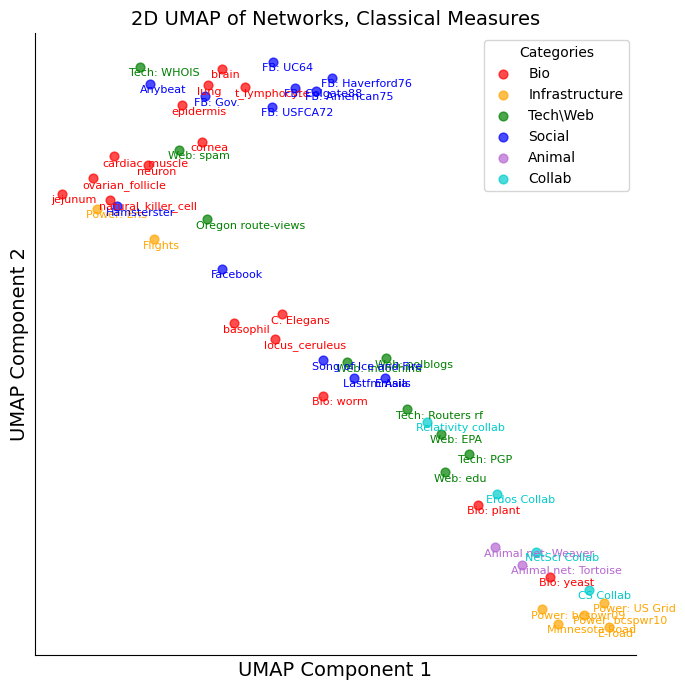

In [ ]:
# Stack data
X = np.vstack([data_bio, data_infrastructure, data_tech, data_social, data_animal, data_collab]) 
names = bio + infrastructure + tech + social + animal + collab 
labels = (["Bio"] * len(bio) + ["Infrastructure"] * len(infrastructure) + 
          ["Tech\Web"] * len(tech) + ["Social"] * len(social) + 
          ["Animal"] * len(animal) + ["Collab"] * len(collab))

# Perform UMAP
umap_model = umap.UMAP(n_components=2, random_state=1038)
X_umap = umap_model.fit_transform(X)

# Define colors
group_colors = {
    "Bio": "red",
    "Infrastructure": "orange",
    "Tech\Web": "green",
    "Social": "blue",
    "Animal": "#B666D2",
    "Collab": "#00CCCC"
}

# Dummy measure for size scaling (replace with real measure if needed)
measure = np.ones((X.shape[0], 1))

# Plot setup
plt.figure(figsize=(7, 7))
typecheck = {label: 0 for label in group_colors}

for i, name in enumerate(names):
    x, y = X_umap[i, 0], X_umap[i, 1]
    label = labels[i]
    color = group_colors[label]
    size = 40 * np.max(measure[i, :])  # Adjust size here

    if typecheck[label] == 0:
        plt.scatter(x, y, color=color, s=size, label=label, alpha=0.7, linewidths=1)
        typecheck[label] = 1
    else:
        plt.scatter(x, y, color=color, s=size, alpha=0.7, linewidths=1)

    # Annotate point
    plt.annotate(name, (x - 0.1, y - 0.15), fontsize=8, color=color)

# Final styling
plt.legend(loc="best", frameon=True, title="Categories")
plt.xlabel("UMAP Component 1", fontsize=14)
plt.ylabel("UMAP Component 2", fontsize=14)
plt.title("2D UMAP of Networks, Classical Measures", fontsize=14)

# Remove axis ticks
plt.xticks([])
plt.yticks([])

sns.despine()
plt.tight_layout()
#plt.savefig("UMAP_Classical_styled.pdf")